# Reproducible Code for: Neutral mutations promote unbounded adaptation after clonal interference.

### Salvador León Fernández, Miguel Ángel Fortuna Alcolado.

We are going to reproduce the figures and statistical analyses from the Results and Discussion section: **The role of clonal interference in early adaptation**.

---

## Setup & Environment

In [3]:
library("tidyverse")
library("scales") 
library("patchwork")

## Data Loading

In [2]:
db_load = read_csv("../../DATA/db_joined_most_abundant_organism.csv",
                   col_types = cols("i", "i", "-", "d", "i", "i", "c", "i", "d", "-", "d", "i")) 

db_load_paired = db_load %>% mutate(rep_id_paired = ifelse(mu == 0.01, rep_id - 200, rep_id))
db_load_paired %>% head(3)
db_load_paired %>% tail(3)

founder_id,env_id,mu,rep_id,sample_update,sequence,abundance,fitness_org_id,relative_fitness,origin_update,rep_id_paired
<int>,<int>,<dbl>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>
1012,1659,0.001,1,0,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1,0.0731707,0,0,1
1012,1659,0.001,1,1000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,9926,0.0731707,0,0,1
1012,1659,0.001,1,2000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,9721,0.0731707,0,0,1


founder_id,env_id,mu,rep_id,sample_update,sequence,abundance,fitness_org_id,relative_fitness,origin_update,rep_id_paired
<int>,<int>,<dbl>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>
5642,1787,0.01,382,493000,faxwehdqeidpnfbyyctybjadihajsevudmcczkkeszwhjfkgpscfaygclmbfacbcdhaftbsldfnahobhoayzyfauwmiuzvvxvvvglu,692,0.180723,1,481015,182
5642,1787,0.01,382,494000,faxwehdqeidpnfbyyctybjadihajsfvudmccztkeszwhjfkgpscfaygclmafacbcdhaftbsldfnaqobhoayzyfanwmiuzvvxvvvghu,736,0.180723,1,481491,182
5642,1787,0.01,382,500000,faxwehdqeidpnfbyyctybjadihajsfvudmccztkzszwhjfkgpscfaygclmafacbcdhaftbsldfnaqobhoayzyfanwmiuzvvxvvvghu,1144,0.180723,1,496262,182


In [4]:
# ==============================================================================
# DATA GENERATION PIPELINE (For Reproducibility Only)
# ==============================================================================
# The following block of code was used to process the massive raw dataset 
# ("DATA/db_mut_supply.csv") and generate the summary file used in this script. 
# It is commented out to save execution time and memory during standard runs, 
# as the final processed file is already provided in the repository.
#
# db_available <- fread("../../DATA/db_mut_supply.csv", colClasses = cls) %>%
#  filter(mut_rate > 0.0005) %>%
#  mutate(relative_fitness = ifelse(update == 0, NA, relative_fitness)) %>%
#  arrange(rep_id, update)
#
# db_available_summary <- db_available %>%
#  filter(
#    !is.na(relative_fitness), 
#    !is.na(mut_rate),
#    resource == "NOT",
#    update != 0                
#  ) %>%
#  mutate(
#    update_bin = ceiling(update / 1000) * 1000, 
#    effect_type = case_when(
#      relative_fitness > 1  ~ "Beneficial",
#      relative_fitness == 1 ~ "Neutral",
#      relative_fitness < 1 & relative_fitness > 0  ~ "Deleterious",
#      relative_fitness == 0  ~ "Lethal"
#    ),
#    effect_type = factor(effect_type, levels = c("Lethal", "Beneficial", "Neutral", "Deleterious")),
#    mut_rate    = factor(mut_rate)
#  ) %>%
#  count(mut_rate, update_bin, effect_type) %>%
#  group_by(mut_rate, update_bin) %>%
#  mutate(percentage = (n / sum(n)) * 100) %>%
#  ungroup()
#
# write_csv(db_available_summary, file = "../../DATA/db_mut_supply_summary.csv")
# ==============================================================================

db_available <- read_csv(file = "../../DATA/db_mut_supply_summary.csv") 
db_available %>% head(3)
db_available %>% tail(3)

Rows: 4000 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): effect_type
dbl (4): mut_rate, update_bin, n, percentage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


mut_rate,update_bin,effect_type,n,percentage
<dbl>,<dbl>,<chr>,<dbl>,<dbl>
0.001,1000,Lethal,11177,47.43856
0.001,1000,Beneficial,3180,13.49688
0.001,1000,Neutral,5156,21.88362


mut_rate,update_bin,effect_type,n,percentage
<dbl>,<dbl>,<chr>,<dbl>,<dbl>
0.01,5e+05,Beneficial,639,0.06806547
0.01,5e+05,Neutral,218020,23.22321427
0.01,5e+05,Deleterious,234766,25.00697698


In [5]:
# ==============================================================================
# DATA GENERATION PIPELINE: BENEFICIAL MUTATIONS ONLY (For Reproducibility)
# ==============================================================================
# The following block of code was used to extract only the beneficial mutations 
# from the massive raw dataset ("DATA/db_mut_supply.csv"). 
# It is commented out to save execution time and memory. The pre-processed 
# output file is provided in the repository.
#
# db_available <- fread("../../DATA/db_mut_supply.csv", colClasses = cls) %>%
#  filter(mut_rate > 0.0005, relative_fitness > 1) %>%
#  mutate(relative_fitness = ifelse(update == 0, NA, relative_fitness)) %>%
#  arrange(rep_id, update)
#
# write_csv(db_available, file = "../../DATA/beneficial_mutations_only.csv")
# ==============================================================================

db_beneficial = read_csv(file = "../../DATA/db_beneficial_mutations_only.csv") %>% filter(mut_rate > 0.0005) %>%
                mutate(rep_id_paired = ifelse(rep_id > 200, rep_id - 200, rep_id))
db_beneficial %>% head(3)
db_beneficial %>% tail(3)

Rows: 1716346 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): resource, mut_type, seq
dbl (10): rep_id, founder_id, env_id, phenotype_id, mut_rate, update, org_id...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,seq,update,org_id,parent_id,fitness_org_id,relative_fitness,rep_id_paired
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1012,1659,1,NOT,0.001,sub,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufcswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,236,27,1,0.0735294,1.00490,1
1,1012,1659,1,NOT,0.001,sub,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaelmrsjlsazvuviixgjudyjaodjfhx,310,62,1,0.0733496,1.00244,1
1,1012,1659,1,NOT,0.001,sub,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxjathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,507,160,1,0.0757576,1.03535,1


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,seq,update,org_id,parent_id,fitness_org_id,relative_fitness,rep_id_paired
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
299,1108,569,1,NOT,0.01,sub,eatncybqubqywzcbbjcadceaerchcwdbzvvvvvvfaxvvgaqbkppmjxyrpskeqdpxwlwqgvkyalkmlkohssjllicieikuvb,481638,6908362,6900424,0.220588,1.00735,99
299,1108,569,1,NOT,0.01,sub,ealncybqubqywpcbbacjaceaarchcwdbzvvvvvvfaxvvgavbkpvmjxyrcepezepiwlwgbdsyawfnlkocsoqmvihcyikuyb,492638,7076572,7076009,0.214286,1.00714,99
299,1108,569,1,NOT,0.01,sub,fatncybqubqywzcbbccaaceaerchcwdbzvvvvvvfaxvvgaqskppmjxyrpskeddpxwlwqgjkyalkmlkohfsjblicieikuvb,498328,7163116,7161765,0.225564,1.00752,99


In [8]:
db_fixed <- read_csv("../../DATA/db_fixed_mutations.csv") %>% mutate(rep_id_paired = ifelse(mut_rate == 0.01, rep_id - 200, rep_id))
db_fixed %>% head(3)
db_fixed %>% tail(3)

Rows: 26735 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): resource, mut_type, sequence
dbl (8): rep_id, founder_id, env_id, phenotype_id, mut_rate, update, fitness...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,update,fitness,relative_fitness,sequence,rep_id_paired
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1,1012,1659,1,NOT,0.001,NA,0,0.0731707,0.00000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1
1,1012,1659,1,NOT,0.001,sub,1911,0.0731707,1.00000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1
1,1012,1659,1,NOT,0.001,sub,8688,0.0757576,1.03535,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,update,fitness,relative_fitness,sequence,rep_id_paired
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
499,1108,569,1,NOT,1e-04,sub,144034,0.0566038,1.93396,unmucybqueqywzjbzqcaobevwrchcovsqzvyptscuahxvsggkzysayvepvefeydxojhgszhdtenukxipgeivlfaputyb,499
499,1108,569,1,NOT,1e-04,ins,149452,0.0757576,1.33838,unmucybqueqywzjbzqcaobevwrchcovsqzvvyptscuahxvsggkzysayvepvefeydxojhgszhdtenukxipgeivlfaputyb,499
499,1108,569,1,NOT,1e-04,sub,496549,0.0821918,1.08493,unmucybqueqywzjbzqcaobevwrchcovsqzvvyptsceahxvsggkzysayvepvefeydxojhgszhdtenukxipgeivlfaputyb,499


---

## Statistical Analysis Function:

In [7]:
perform_paired_analysis <- function(data, rep_col, cond_col, val_col, group1, group2) {
  
  # Reshape data to pair observations side-by-side
  df_paired <- data %>%
    select(all_of(c(rep_col, cond_col, val_col))) %>%
    pivot_wider(names_from = all_of(cond_col), values_from = all_of(val_col)) %>%
    drop_na() # Drop incomplete pairs
  
  vec_g1 <- df_paired[[group1]]
  vec_g2 <- df_paired[[group2]]
  differences <- vec_g1 - vec_g2
  
  # Check normality of differences to choose the right test
  shapiro_res <- shapiro.test(differences)
  
  cat("\n--------------------------------------------------\n")
  cat("1. NORMALITY TEST RESULTS (Shapiro-Wilk)\n")
  cat("--------------------------------------------------\n")
  cat("P-value:", round(shapiro_res$p.value, 5), "\n\n")
  
  if (shapiro_res$p.value > 0.05) {
    
    cat("=> Differences FOLLOW a normal distribution (p > 0.05).\n")
    cat("=> Running Paired T-Test (Parametric)...\n\n")
    
    stat_test_res <- t.test(vec_g1, vec_g2, paired = TRUE)
    
  } else {
    
    cat("=> Differences DO NOT follow a normal distribution (p < 0.05).\n")
    cat("=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...\n\n")
    
    # exact = FALSE avoids warnings with zero-differences (ties)
    stat_test_res <- wilcox.test(vec_g1, vec_g2, paired = TRUE, exact = FALSE) 
  }
  
  cat("--------------------------------------------------\n")
  cat("2. STATISTICAL TEST RESULTS\n")
  cat("--------------------------------------------------\n")
  print(stat_test_res)
  
  # Plot the distribution of differences
  p_diff <- ggplot(data.frame(diff = differences), aes(x = diff)) +
    geom_density(fill = "gray80", alpha = 0.5, color = "black") +
    geom_vline(xintercept = 0, linetype = "dashed", color = "red", linewidth = 1) +
    labs(title = "Distribution of Paired Differences",
         subtitle = paste("Selected test:", stat_test_res$method),
         x = paste("Difference (", group1, "-", group2, ")"),
         y = "Density") +
    theme_minimal()
  
  print(p_diff)
  
  # Return objects silently so they can be saved to a variable later
  invisible(list(
    shapiro = shapiro_res,
    stat_test = stat_test_res,
    plot = p_diff
  ))
}

---

## Statistical Analysis & Figure Generation

In [43]:
# ==============================================================================
# FIGURE EXPORT TEMPLATE (Optional)
# ==============================================================================
# If you wish to extract and save any of the generated plots in high resolution,
# you can uncomment and use the following base template. 
# Just replace 'your_plot_variable' with the actual name of the plot object 
# you want to save (e.g., relative_fitness_ci, final_plot, etc.).

# dir.create("Figures", showWarnings = FALSE)

# ggsave(
#   filename = "Figures/your_figure_name.png", 
#   plot     = your_plot_variable, 
#   width    = 5, 
#   height   = 6, 
#   units    = "in", 
#   dpi      = 600, 
#   bg       = "white", 
#   scale    = 1.2
# )

### Figure 2A-B Fitness trajectories & beneficial mutational supply:

#### Figure 2A

In [10]:
normalized_data <- db_load %>%
  filter(sample_update >= 0) %>%
  group_by(founder_id) %>%
  mutate(
    min_fit        = min(fitness_org_id, na.rm = TRUE),
    max_fit        = max(fitness_org_id, na.rm = TRUE),
    fitness_scaled = ifelse(max_fit > min_fit,
                            (fitness_org_id - min_fit) / (max_fit - min_fit), 0)
  ) %>%
  ungroup()
normalized_data %>% head(3)
normalized_data %>% tail(3)

founder_id,env_id,mu,rep_id,sample_update,sequence,abundance,fitness_org_id,relative_fitness,origin_update,min_fit,max_fit,fitness_scaled
<int>,<int>,<dbl>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
1012,1659,0.001,1,0,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1,0.0731707,0,0,0.0731707,0.172414,0
1012,1659,0.001,1,1000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,9926,0.0731707,0,0,0.0731707,0.172414,0
1012,1659,0.001,1,2000,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxgathsvjtxkzzgpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,9721,0.0731707,0,0,0.0731707,0.172414,0


founder_id,env_id,mu,rep_id,sample_update,sequence,abundance,fitness_org_id,relative_fitness,origin_update,min_fit,max_fit,fitness_scaled
<int>,<int>,<dbl>,<int>,<int>,<chr>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
5642,1787,0.01,382,493000,faxwehdqeidpnfbyyctybjadihajsevudmcczkkeszwhjfkgpscfaygclmbfacbcdhaftbsldfnahobhoayzyfauwmiuzvvxvvvglu,692,0.180723,1,481015,0.0652174,0.180723,1
5642,1787,0.01,382,494000,faxwehdqeidpnfbyyctybjadihajsfvudmccztkeszwhjfkgpscfaygclmafacbcdhaftbsldfnaqobhoayzyfanwmiuzvvxvvvghu,736,0.180723,1,481491,0.0652174,0.180723,1
5642,1787,0.01,382,500000,faxwehdqeidpnfbyyctybjadihajsfvudmccztkzszwhjfkgpscfaygclmafacbcdhaftbsldfnaqobhoayzyfanwmiuzvvxvvvghu,1144,0.180723,1,496262,0.0652174,0.180723,1


In [14]:
summary_data <- normalized_data %>%
  group_by(sample_update, mu) %>%
  summarise(
    mean_fitness = mean(fitness_scaled, na.rm = TRUE),
    sd_fitness   = sd(fitness_scaled,   na.rm = TRUE),
    n_replicas   = n(),
    se_fitness   = sd_fitness / sqrt(n_replicas),
    moe          = ifelse(n_replicas > 1,
                          qt(0.975, df = n_replicas - 1) * se_fitness, 0),
    ymin_ci      = mean_fitness - moe,
    ymax_ci      = mean_fitness + moe,
    .groups      = "drop"
  ) %>%
  mutate(mu_factor = factor(mu,
                            levels = c(0.001, 0.01),
                            labels = c("Low (0.001)", "High (0.01)")))

summary_data <- normalized_data %>%
  group_by(sample_update, mu) %>%
  summarise(
    mean_fitness = mean(fitness_scaled, na.rm = TRUE),
    sd_fitness   = sd(fitness_scaled,   na.rm = TRUE),
    n_replicas   = n(),
    se_fitness   = sd_fitness / sqrt(n_replicas),
    moe          = ifelse(n_replicas > 1,
                          qt(0.975, df = n_replicas - 1) * se_fitness, 0),
    ymin_ci      = mean_fitness - moe,
    ymax_ci      = mean_fitness + moe,
    .groups      = "drop"
  ) %>%
  mutate(mu_factor = factor(mu,
                            levels = c(0.001, 0.01),
                            labels = c("Low (0.001)", "High (0.01)")))

p_fitness <- ggplot(summary_data,
       aes(x = sample_update, y = mean_fitness, color = mu_factor)) +
  geom_vline(xintercept = 50000, linetype = "dashed",
             color = "black", linewidth = 0.8, alpha = 0.7) +
  geom_errorbar(aes(ymin = ymin_ci, ymax = ymax_ci),
                width = 0, alpha = 0.4) +
  geom_line(linewidth = 1, alpha = 0.8) +
  geom_point(size = 1, alpha = 0.4) +
  scale_x_continuous(labels = function(x) x / 100000) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     limits = c(0, 1), expand = c(0, 0.02)) +
  scale_color_discrete(name = "Mutation Rate:") +
  guides(color = guide_legend(override.aes = list(linewidth = 2.5, size = 3))) +
  labs(
    x     = expression(paste("Time (Updates [", "" %*% 10^5, "])")),
    y     = "Min-Max Normalized Fitness (%)",
    color = "Mutation Rate:"
  ) +
  theme_bw() +
  theme(
    strip.text         = element_text(size = 18),
    strip.background   = element_blank(),
    axis.title.x       = element_text(size = 18, margin = margin(t = 0), color = "black"),
    axis.title.y       = element_text(size = 18, margin = margin(r = 0), color = "black"),
    axis.text.x        = element_text(color = "black", size = 16),
    axis.text.y        = element_text(color = "black", size = 16),
    axis.ticks         = element_line(linewidth = 0.5),
    axis.ticks.length  = unit(0.25, "cm"),
    panel.border       = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major   = element_line(color = "gray90", linetype = "solid"),
    panel.grid.minor   = element_blank(),
    legend.position    = "none"   
  )

#### Figure 2B

In [16]:
p_beneficial <- ggplot(
    db_available %>%
      filter(effect_type == "Beneficial") %>%
      mutate(mu_factor = factor(mut_rate,
                                levels = c(0.001, 0.01),
                                labels = c("Low (0.001)", "High (0.01)"))),
    aes(x = update_bin, y = percentage, color = mu_factor)) +
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "black", linewidth = 0.8, alpha = 0.6) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5, alpha = 0.7) +
  scale_x_continuous(labels = function(x) x / 100000) +
  scale_y_continuous(limits = c(0, NA),
                     expand = expansion(mult = c(0, 0.05))) +
  scale_color_discrete(name = "Mutation Rate:") +
  guides(color = "none") + 
  labs(
    x     = expression(paste("Time (Updates [", "" %*% 10^5, "])")),
    y     = "Frequency of beneficial mutation supply (%)",
    color = "Mutation Rate:"
  ) +
  theme_bw() +
  theme(
    strip.text        = element_text(size = 18),
    strip.background  = element_blank(),
    axis.title.x      = element_text(size = 18, margin = margin(t = 5), color = "black"),
    axis.title.y      = element_text(size = 18, margin = margin(r = 5), color = "black"),
    axis.text.x       = element_text(color = "black", size = 16),
    axis.text.y       = element_text(color = "black", size = 16),
    axis.ticks        = element_line(linewidth = 0.5),
    axis.ticks.length = unit(0.25, "cm"),
    panel.border      = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major  = element_line(color = "gray90", linetype = "solid"),
    panel.grid.minor  = element_blank(),
    legend.position   = "none"   
  )

#### COMBINE

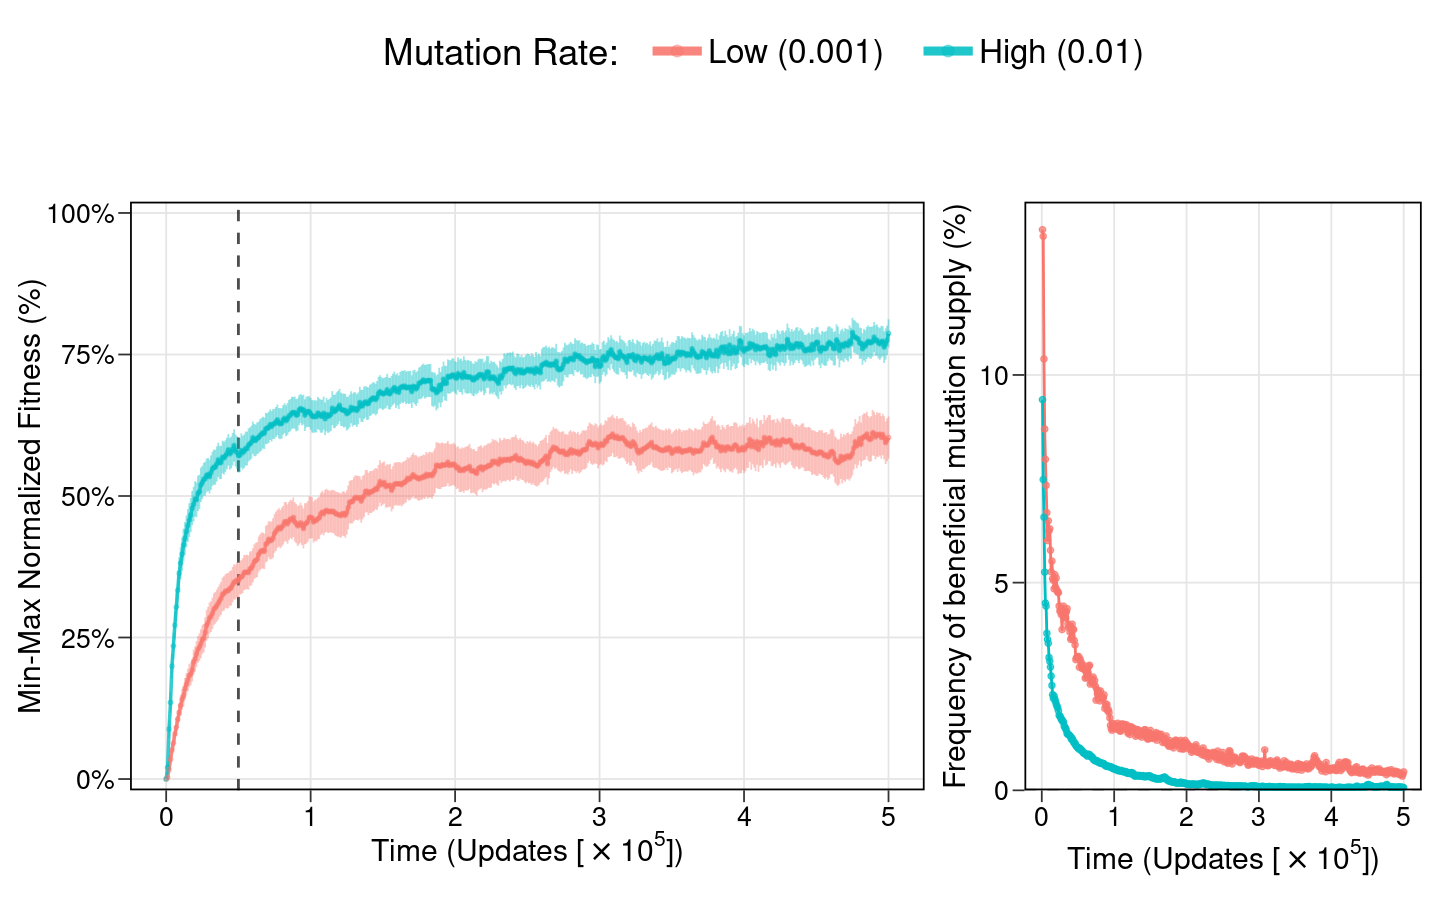

In [17]:
options(repr.plot.width = 12, repr.plot.height = 7.5)

combined <- (p_fitness | p_beneficial) +
  plot_layout(guides = "collect", widths = c(1.6, 0.8)) &
  theme(
    legend.position      = "top",
    legend.justification = "center",
    
    legend.title         = element_text(size = 22, margin = margin(r = 15)),
    legend.text          = element_text(size = 20, margin = margin(r = 15)),
    
    legend.key.width     = unit(1.3, "cm"),
    legend.key.size      = unit(1.0, "cm"),
    
    legend.box.margin    = margin(b = 60) 
  )

combined

### Statistical analysis Figure 2A-B: Fitness difference & beneficial supply decay

#### Fitness at the beginning:

In [18]:
fitness_50K <- db_beneficial %>%
  filter(update <= 50000, mut_rate > 0.0005) %>%
  group_by(rep_id_paired, mut_rate) %>%
  slice_max(order_by = update, n = 1, with_ties = FALSE) %>%
  ungroup()

table(fitness_50K$mut_rate)


0.001  0.01 
  200   200 


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0.03749 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 1100, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



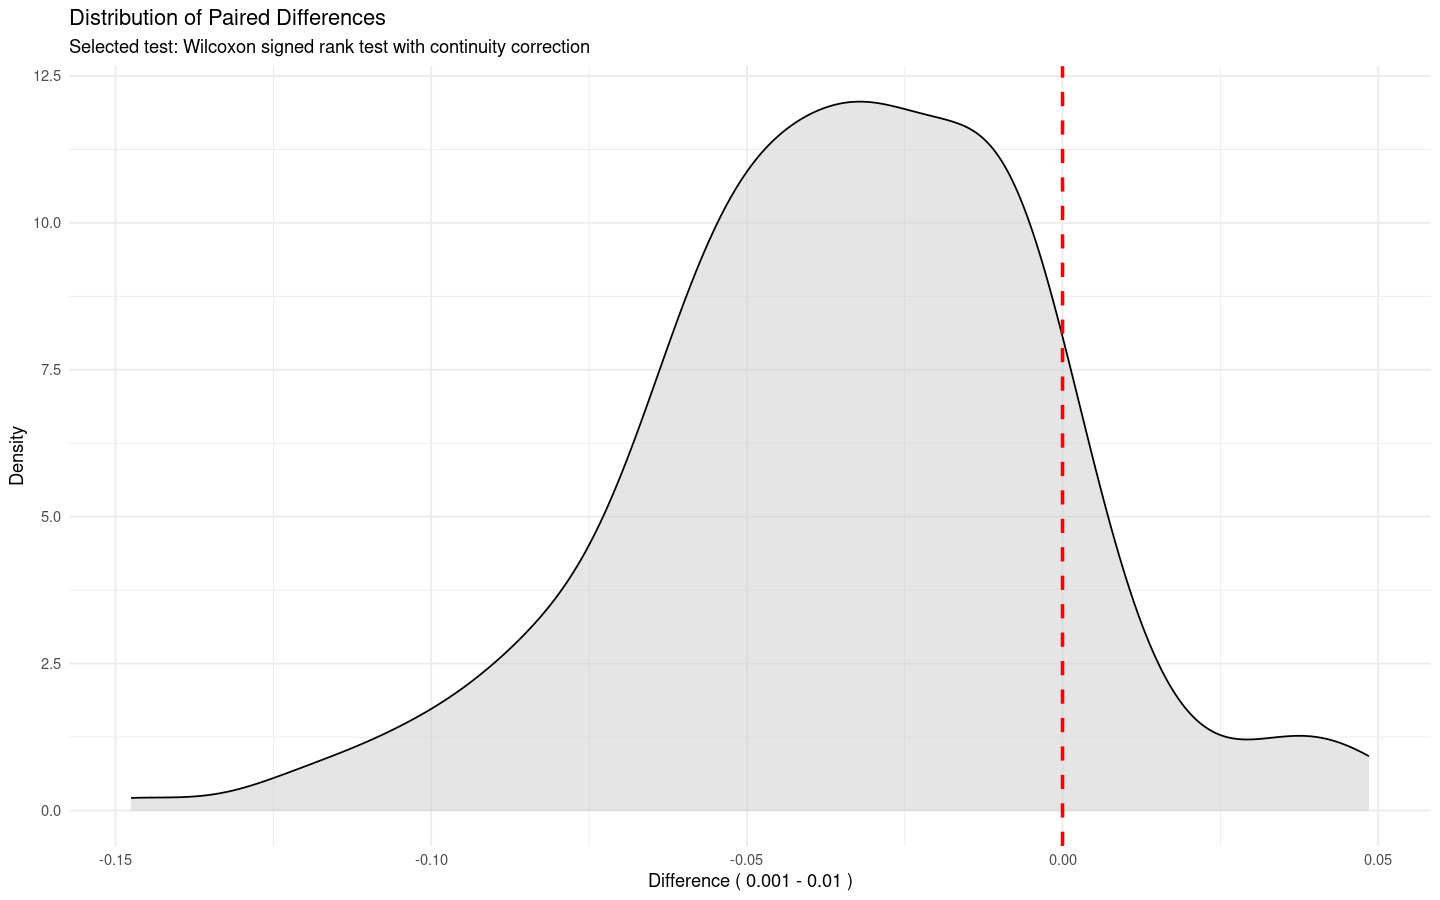

In [19]:
resultados_50k <- perform_paired_analysis(
  data      = fitness_50K, 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate",                
  val_col   = "fitness_org_id",        
  group1    = "0.001",             
  group2    = "0.01"               
)

#### Fitness at the end:

In [20]:
fitness_500K <- db_beneficial %>%
  filter(update <= 500000, mut_rate > 0.0005) %>%
  group_by(rep_id_paired, mut_rate) %>%
  slice_max(order_by = update, n = 1, with_ties = FALSE) %>%
  ungroup()

table(fitness_500K$mut_rate)


0.001  0.01 
  200   200 


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 3184, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



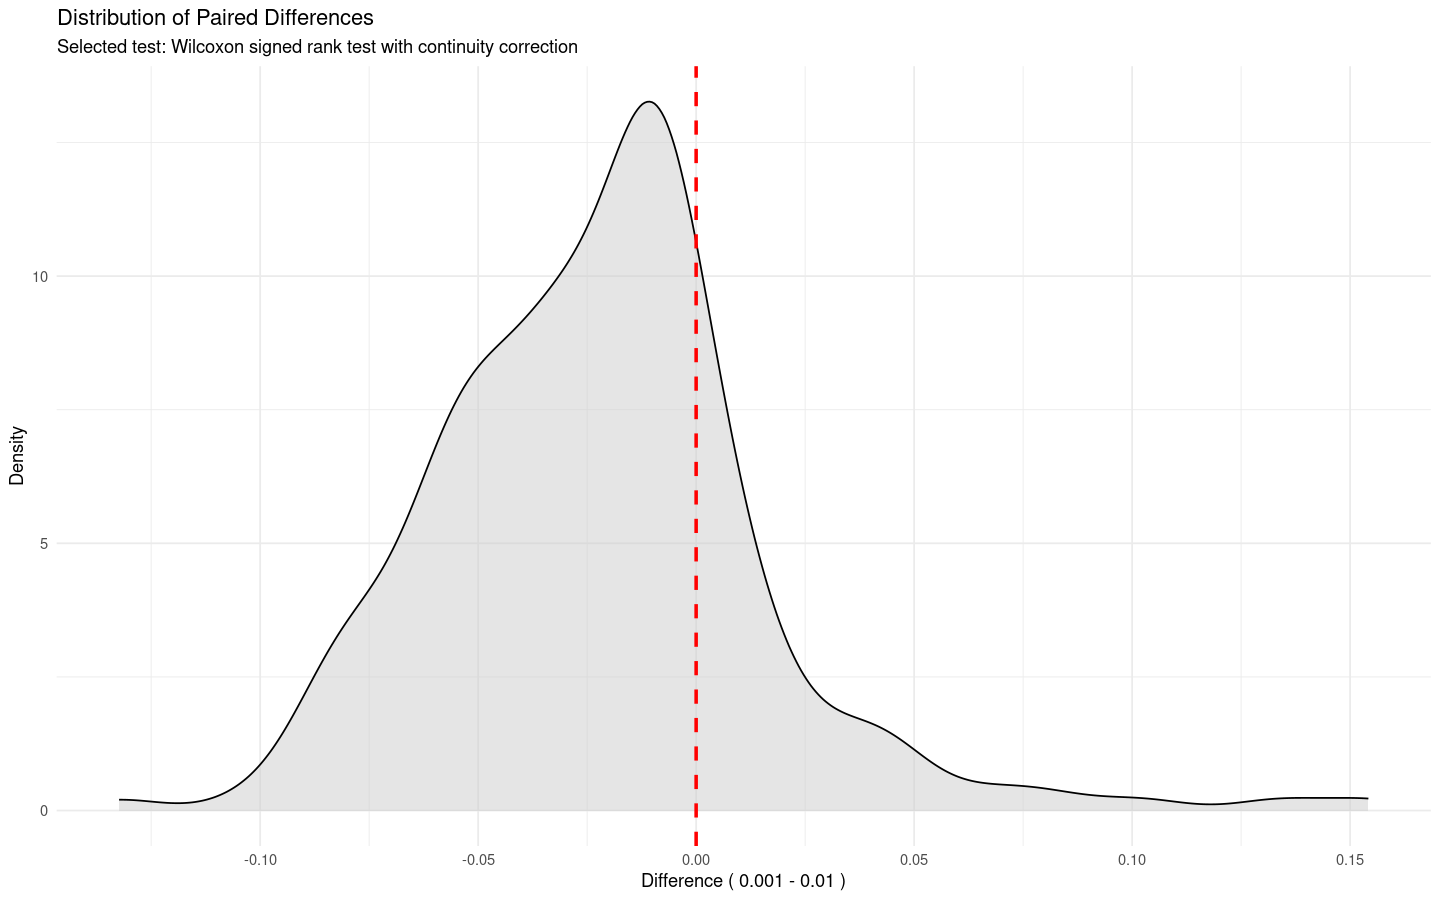

In [21]:
resultados_500k <- perform_paired_analysis(
  data      = fitness_500K, 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate",                
  val_col   = "fitness_org_id",        
  group1    = "0.001",             
  group2    = "0.01"               
)

#### Beneficial supply decay rate

In [6]:
# Format data and scale percentage to a proportion
db_model <- db_available %>%
  filter(effect_type == "Beneficial") %>%
  mutate(
    # Convert to factor so as.numeric() maps levels to 1 and 2
    mut_rate_factor = factor(mut_rate, levels = c(0.001, 0.01)),
    proportion = percentage / 100 
  )

# Fit exponential decay model
model_p_mut <- nls(
  proportion ~ a * exp(-(b0 + b1 * as.numeric(mut_rate_factor)) * update_bin),
  data = db_model,
  start = list(a = 0.13, b0 = 0.000001, b1 = 0.000001)
)

summary(model_p_mut)

# Extract coefficients and compute decay rates per condition
b0 <- coef(model_p_mut)["b0"]
b1 <- coef(model_p_mut)["b1"]

rate_low  <- b0 + b1 * 1
rate_high <- b0 + b1 * 2

cat("Rate Low (0.001):", rate_low, "\n")
cat("Rate High (0.01):", rate_high, "\n")


Formula: proportion ~ a * exp(-(b0 + b1 * as.numeric(mut_rate_factor)) * 
    update_bin)

Parameters:
     Estimate Std. Error t value Pr(>|t|)    
a   6.764e-02  1.002e-03   67.48   <2e-16 ***
b0 -2.515e-05  1.681e-06  -14.96   <2e-16 ***
b1  3.668e-05  1.696e-06   21.63   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.005099 on 997 degrees of freedom

Number of iterations to convergence: 20 
Achieved convergence tolerance: 9.17e-06


Rate Low (0.001): 1.152848e-05 
Rate High (0.01): 4.820533e-05 


---

### Figure 2C Evidence of lonal interference:

In [23]:
db_n_mut_beneficial <- db_beneficial %>%
    mutate(time_window = floor(update / 10) * 10) %>%
    count(rep_id_paired, mut_rate, time_window) %>%
    filter(n > 0)

db_n_mut_beneficial %>% head(3)
db_n_mut_beneficial %>% tail(3)

rep_id_paired,mut_rate,time_window,n
<dbl>,<dbl>,<dbl>,<int>
1,0.001,230,1
1,0.001,310,1
1,0.001,500,1


rep_id_paired,mut_rate,time_window,n
<dbl>,<dbl>,<dbl>,<int>
200,0.01,497580,1
200,0.01,497620,1
200,0.01,499510,1


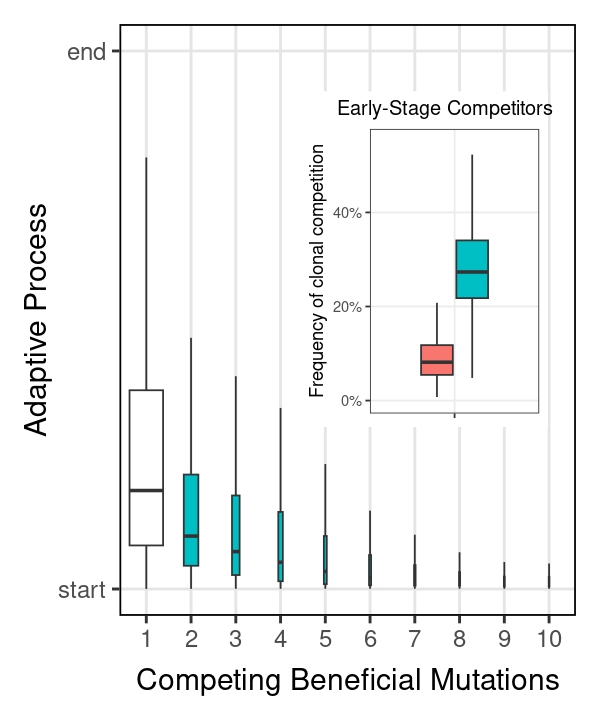

In [24]:
# Set plot dimensions for Jupyter/RMarkdown rendering
options(repr.plot.width = 5, repr.plot.height = 6)

# 1. Prepare data for the main plot (High mutation rate only)
df_main <- db_n_mut_beneficial %>%
  filter(n <= 10, mut_rate == 0.01) %>% 
  group_by(rep_id_paired, n) %>%  
  mutate(interference_state = ifelse(n == 1, "none", "interference"))

# 2. Prepare data for the inset plot (Early-stage competition frequency)
df_freq <- db_n_mut_beneficial %>%
  filter(time_window < 50000) %>% 
  mutate(clonal_int = ifelse(n >= 2, "competitor", "non-competitor")) %>%
  group_by(mut_rate, rep_id_paired, clonal_int) %>%
  summarise(freq_count = n(), .groups = "drop_last") %>%
  mutate(rel_freq = freq_count / sum(freq_count)) %>%
  filter(clonal_int == "competitor") %>%
  ungroup()
               
# 3. Generate main boxplot: Timing of competing beneficial mutations
p_main <- ggplot(df_main, aes(x = factor(n), y = time_window, fill = interference_state)) +
  geom_boxplot(varwidth = TRUE, outlier.shape = NA) +  
  # White for n=1 (no interference), Turquoise for n>=2 (interference)
  scale_fill_manual(values = c("none" = "white", "interference" = "#00BFC4")) +
  
  scale_y_continuous(
    breaks = c(0, 500000),
    labels = c("start", "end"),
  ) +
  
  labs(
    x = "Competing Beneficial Mutations",
    y = "Adaptive Process"
  ) +
  
  theme_bw(base_size = 18) +
  theme(
    legend.position    = "none",
    axis.title.x       = element_text(size = 18, margin = margin(t = 10)),
    axis.title.y       = element_text(size = 18),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major = element_line(color = "gray90", linetype = "solid"),
    panel.grid.minor = element_blank(),
  )

# 4. Generate inset boxplot: Frequency of early-stage competitors
p_inset <- ggplot(df_freq, aes(x = clonal_int, y = rel_freq, fill = factor(mut_rate))) +
 geom_boxplot(width = 0.5, outlier.shape = NA) +

  scale_y_continuous(
    labels = scales::label_percent(accuracy = 1)
  ) +
  coord_cartesian(ylim = c(0,0.55)) +
  labs(
    title = "Early-Stage Competitors",
    x = NULL,
    y = "Frequency of clonal competition",
    fill = "Mutation Rate"
  ) +
  
  theme_bw(base_size = 11) +
  theme(
    plot.title         = element_text(size = 12, hjust = 0.7),
    plot.background    = element_rect(fill = "white", color = "transparent", linewidth = 0.5), 
    legend.position    = "none",
    legend.title       = element_text(size = 9),
    legend.text        = element_text(size = 8),
    legend.key.size    = unit(0.4, "cm"),
    legend.margin      = margin(t = -5),
    panel.grid.minor   = element_blank(),
    axis.text.x = element_blank()
  )

# 5. Assemble final figure combining main and inset plots
final_plot <- p_main + 
  inset_element(p_inset, left = 0.50, bottom = 0.4, right = 0.95, top = 0.90, align_to = "plot")

final_plot

In [46]:
# DESCRIPTIVE STATS INSET BOXPLOT:
summary_inset <- df_freq %>%
  group_by(mut_rate) %>%
  summarise(
    median_freq = median(rel_freq) * 100,
    q1_freq     = quantile(rel_freq, 0.25) * 100,
    q3_freq     = quantile(rel_freq, 0.75) * 100,
    .groups     = "drop"
  )
summary_inset

mut_rate,median_freq,q1_freq,q3_freq
<dbl>,<dbl>,<dbl>,<dbl>
0.001,8.154031,5.456705,11.78060
0.010,27.333734,21.775505,34.04633


### Statistical analysis Figure 2C, inset boxplot:

In [29]:
df_freq %>% filter(rep_id_paired %in% c(1,2,3))

mut_rate,rep_id_paired,clonal_int,freq_count,rel_freq
<dbl>,<dbl>,<chr>,<int>,<dbl>
0.001,1,competitor,8,0.03418803
0.001,2,competitor,256,0.18537292
0.001,3,competitor,17,0.04857143
0.010,1,competitor,317,0.20664928
0.010,2,competitor,966,0.44210526
0.010,3,competitor,332,0.19460727



--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 10, p-value < 2.2e-16
alternative hypothesis: true location shift is not equal to 0



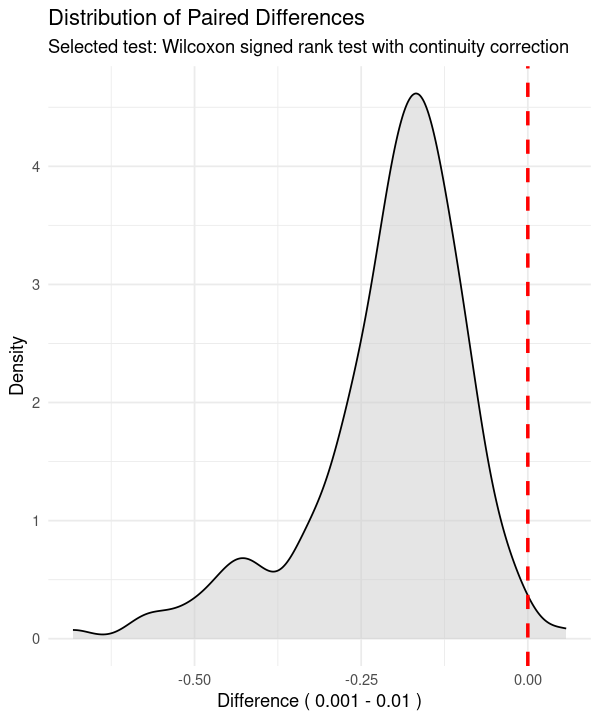

In [30]:
inset_results <- perform_paired_analysis(
  data      = df_freq, 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate", 
  val_col   = "rel_freq",   
  group1    = "0.001",      
  group2    = "0.01"       
)

---

### Figure 2D, fitness gains at the same fixation step:

In [ ]:
# 1. Apply min-max scaling per founder lineage
df_scaled <- db_fixed %>%
    filter(mut_rate > 0.0005) %>%
    group_by(founder_id) %>%
    mutate(
        min_fit = min(fitness, na.rm = TRUE),
        max_fit = max(fitness, na.rm = TRUE),
        fitness_scaled = ifelse(max_fit > min_fit, 
                                (fitness - min_fit) / (max_fit - min_fit), 
                                0)
    ) %>%
    ungroup() %>%
    mutate(
        rep_id_paired = ifelse(rep_id > 200, rep_id - 200, rep_id),
        mu_label = factor(ifelse(mut_rate == 0.01, "High (0.01)", "Low (0.001)"), 
                          levels = c("Low (0.001)", "High (0.01)"))
    )

# 2. Build the fixation trajectory of mutations
df_traj <- df_scaled %>%
    group_by(mut_rate, rep_id_paired) %>%
    arrange(update, .by_group = TRUE) %>%
    mutate(step_size = fitness - lag(fitness)) %>%
    filter(step_size > 0) %>%
    mutate(fixation_order = row_number()) %>%
    ungroup()

# 3. Limit comparison to the first 9 fixed mutations
MAX_ORDER <- 9

df_plot <- df_traj %>% filter(fixation_order <= MAX_ORDER)

# 4. Calculate median trajectory of fitness scaled for the background lines
median_fitness <- df_plot %>%
    group_by(mu_label, fixation_order) %>%
    summarise(median_fit_scaled = median(fitness_scaled, na.rm = TRUE), .groups = "drop")

# 5. Dual-axis mathematical scaling logic
Y_MIN_VISUAL <- 0.95
Y_MAX_VISUAL <- 2.5 

rf_min <- Y_MIN_VISUAL
rf_max <- Y_MAX_VISUAL 

fit_min <- min(median_fitness$median_fit_scaled, na.rm = TRUE)
fit_max <- max(median_fitness$median_fit_scaled, na.rm = TRUE)

scale_fit   <- function(x) rf_min + (x - fit_min) / (fit_max - fit_min) * (rf_max - rf_min)
unscale_fit <- function(x) fit_min + (x - rf_min) / (rf_max - rf_min) * (fit_max - fit_min)

median_fitness <- median_fitness %>%
    mutate(fit_scaled = scale_fit(median_fit_scaled))

# 6. Generate final hybrid plot
options(repr.plot.width = 5.5, repr.plot.height = 6)

relative_fitness_ci = ggplot() +
    geom_line(
        data      = median_fitness,
        aes(x     = fixation_order,
            y     = fit_scaled,
            color = mu_label,
            group = mu_label),
        linewidth = 1.0,
        alpha     = 0.35,
        linetype  = "solid"
    ) +
    geom_boxplot(
        data      = df_plot,
        aes(x    = fixation_order,
            y    = step_size,
            fill = mu_label,
            group = interaction(fixation_order, mu_label)),
        width         = 0.7,
        outlier.size  = 0.7,
        outlier.alpha = 0.4,
        color         = "black",
        outlier.shape = NA,
        linewidth     = 0.5,
        position      = position_dodge2(width = 0.8)
    ) +
    coord_cartesian(ylim = c(0, 0.036)) +
    scale_x_continuous(breaks = 1:MAX_ORDER) +
    scale_y_continuous(
        name = "Fitness Gains of Fixed Beneficial Mutations"
    ) +
    labs(
        x    = "Timing of Fixed Mutations",
        fill = "Mutation Rate:",
        color = "Mutation Rate:"
    ) +
    theme_bw() +
    theme(
        plot.title         = element_blank(),
        axis.title.x       = element_text(size = 18, margin = margin(t = 15)),
        axis.title.y       = element_text(size = 18, margin = margin(r = 5)),
        axis.text.x        = element_text(color = "black", size = 14),
        axis.text.y        = element_text(color = "black", size = 14),
        axis.ticks         = element_line(linewidth = 0.5),
        axis.ticks.length  = unit(0.1, "cm"),
        panel.border       = element_rect(color = "black", fill = NA, linewidth = 1),
        panel.grid.major   = element_line(color = "gray90", linetype = "solid"),
        panel.grid.major.x = element_blank(),
        legend.position    = "none"
    )

relative_fitness_ci

### Statistical analysis Figure 2D, first 5 steps:

In [37]:
df_plot %>% head(3)
df_plot %>% tail(3)

rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,update,fitness,relative_fitness,sequence,rep_id_paired,min_fit,max_fit,fitness_scaled,mu_label,step_size,fixation_order
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<int>
1,1012,1659,1,NOT,0.001,sub,8688,0.0757576,1.03535,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviixgjudyjaodjfhx,1,0.0731707,0.172414,0.02606624,Low (0.001),0.0025869,1
1,1012,1659,1,NOT,0.001,sub,25860,0.0867052,1.14451,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviaxgjudyjaodjfhx,1,0.0731707,0.172414,0.13637696,Low (0.001),0.0109476,2
1,1012,1659,1,NOT,0.001,ins,38954,0.1060070,1.22261,qmwuukrmwxqyqruiytjaalgcirofzhipufxpufkswxkathsvjtxkzztpmpojwqyetaaopwaklmrsjlsazvuviaxvgjudyjaodjfhx,1,0.0731707,0.172414,0.33086667,Low (0.001),0.0193018,3


rep_id,founder_id,env_id,phenotype_id,resource,mut_rate,mut_type,update,fitness,relative_fitness,sequence,rep_id_paired,min_fit,max_fit,fitness_scaled,mu_label,step_size,fixation_order
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<int>
400,1317,1787,1,NOT,0.01,del,11211,0.125523,1.01255,zlwksjcfrc*daxqhcsqfevyqzncxvuvevyvvgmksloqadwzozhucorjyqaymfotobgebphqdvzqdskbhfvucmogoslveciuahpbl,200,0.0152827,0.184049,0.6532128,High (0.01),0.001556,7
400,1317,1787,1,NOT,0.01,sub,34126,0.126050,1.00420,zlwkbjcfrcdaxqhcsqfevyqzncxvuvevyvvgmksloqadwzozetcorjyqaymfotobgebphqdvoqdskbhfvucmogoslveciuhbpbl,200,0.0152827,0.184049,0.6563354,High (0.01),0.000527,8
400,1317,1787,1,NOT,0.01,sub,61640,0.126582,1.00422,zlwkbjcfrcdaxqhcsqfevyczncxvuvevyvvgmksloqadwzozntcorjyqaemfotobgebphadvoqdskbhfvucmogoslveciuhbpbl,200,0.0152827,0.184049,0.6594877,High (0.01),0.000532,9



--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 3346, p-value = 5.228e-08
alternative hypothesis: true location shift is not equal to 0



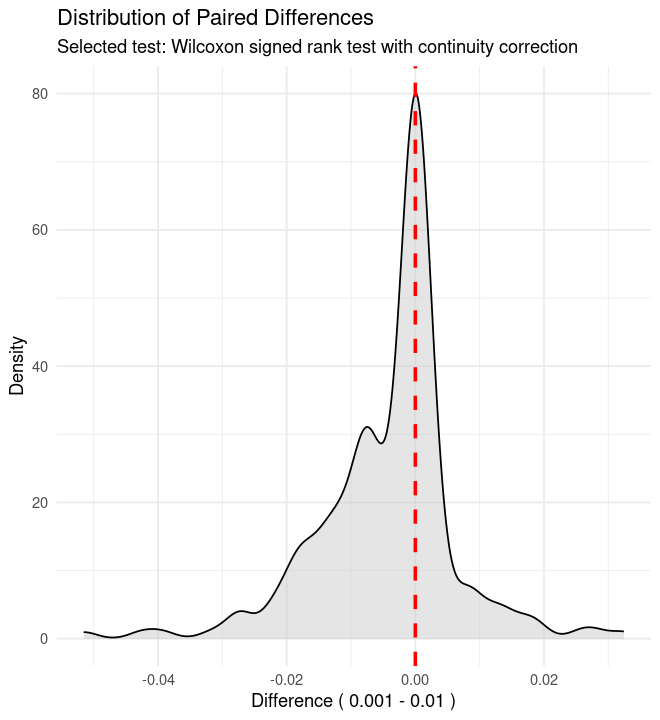

In [38]:
step_1 <- perform_paired_analysis(
  data      = df_plot %>% filter(fixation_order == 1), 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate", 
  val_col   = "step_size",   
  group1    = "0.001",      
  group2    = "0.01"       
)


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 8e-05 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 6209.5, p-value = 0.0001103
alternative hypothesis: true location shift is not equal to 0



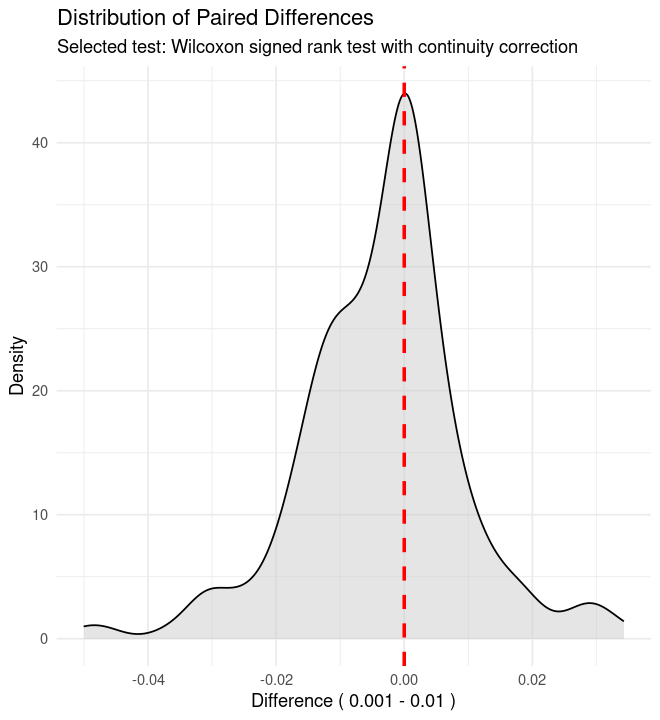

In [39]:
step_1 <- perform_paired_analysis(
  data      = df_plot %>% filter(fixation_order == 2), 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate", 
  val_col   = "step_size",   
  group1    = "0.001",      
  group2    = "0.01"       
)


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 2e-05 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 6455, p-value = 5.79e-05
alternative hypothesis: true location shift is not equal to 0



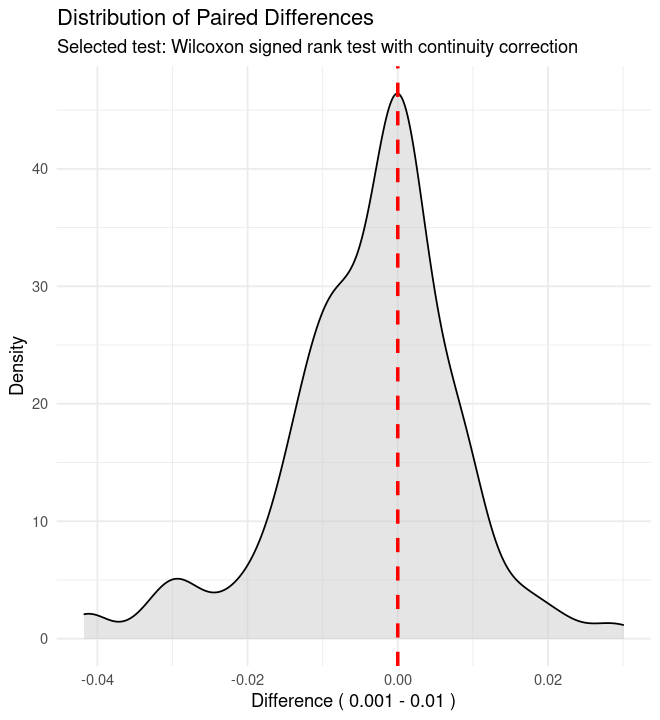

In [40]:
step_1 <- perform_paired_analysis(
  data      = df_plot %>% filter(fixation_order == 3), 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate", 
  val_col   = "step_size",   
  group1    = "0.001",      
  group2    = "0.01"       
)


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0.00102 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 7790, p-value = 0.007936
alternative hypothesis: true location shift is not equal to 0



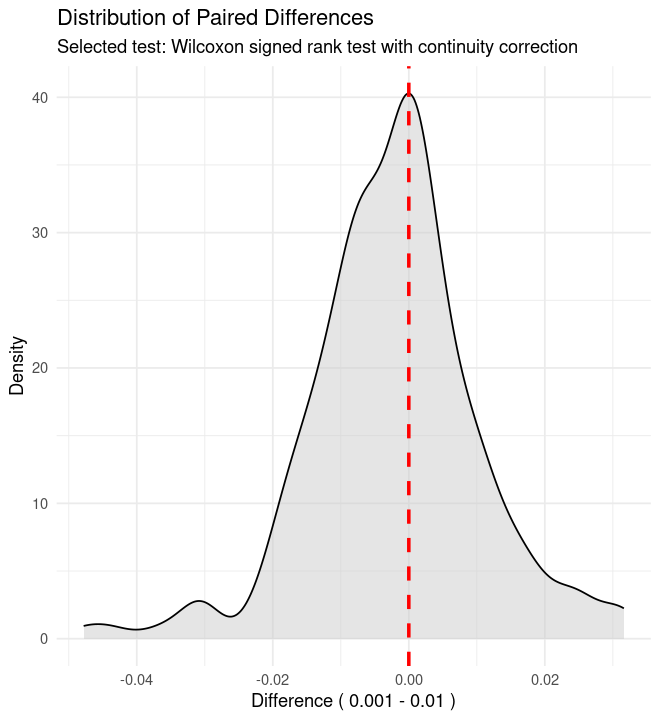

In [41]:
step_1 <- perform_paired_analysis(
  data      = df_plot %>% filter(fixation_order == 4), 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate", 
  val_col   = "step_size",   
  group1    = "0.001",      
  group2    = "0.01"       
)


--------------------------------------------------
1. NORMALITY TEST RESULTS (Shapiro-Wilk)
--------------------------------------------------
P-value: 0.00095 

=> Differences DO NOT follow a normal distribution (p < 0.05).
=> Running Paired Wilcoxon Signed-Rank Test (Non-parametric)...

--------------------------------------------------
2. STATISTICAL TEST RESULTS
--------------------------------------------------

	Wilcoxon signed rank test with continuity correction

data:  vec_g1 and vec_g2
V = 9086, p-value = 0.4066
alternative hypothesis: true location shift is not equal to 0



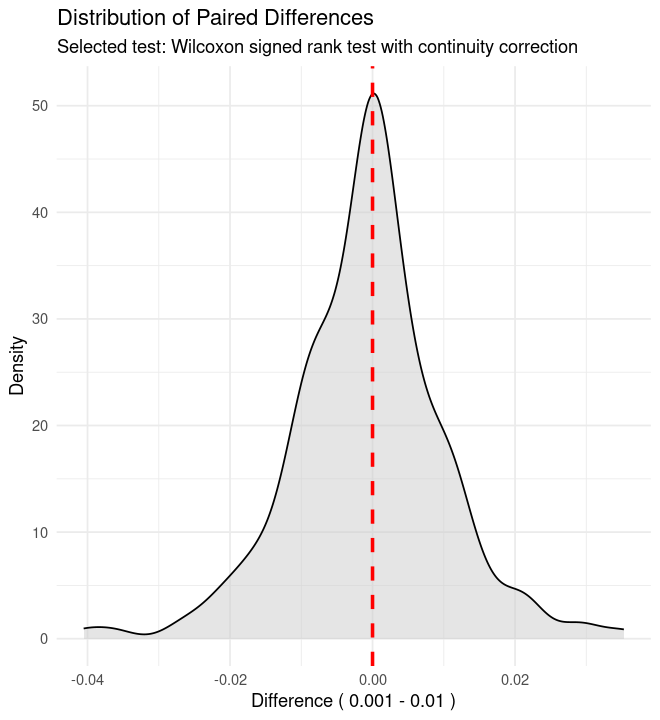

In [42]:
step_1 <- perform_paired_analysis(
  data      = df_plot %>% filter(fixation_order == 5), 
  rep_col   = "rep_id_paired",     
  cond_col  = "mut_rate", 
  val_col   = "step_size",   
  group1    = "0.001",      
  group2    = "0.01"       
)

---

## Reproducibility Session Info

In [11]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-pc-linux-gnu (64-bit)
Running under: Ubuntu 20.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/liblapack.so.3

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.0 scales_1.3.0    lubridate_1.9.4 forcats_1.0.0  
 [5] stringr_1.5.1   dplyr_1.1.4     purrr_1.0.4     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1

---
---